In [2]:
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# PART 1: DATA LOADING & PREPROCESSING


In [4]:
def prepare_data(file_path):
    df = pd.read_csv(file_path)


    genuine_user = 's002'
    df['is_genuine'] = (df['subject'] == genuine_user).astype(int)


    X = df.filter(regex=r'H\.|DD\.|UD\.')
    y = df['is_genuine']

    return train_test_split(X, y, test_size=0.3, random_state=42)

# ENSEMBLE VOTING GENERATOR


In [5]:
class EnsembleVotingGenerator:
    def __init__(self):
        self.svm = SVC(probability=True)
        self.rf = RandomForestClassifier(n_estimators=100)
        self.mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500)
        self.scaler = StandardScaler()

    def train(self, X_train, y_train):
        X_scaled = self.scaler.fit_transform(X_train)
        self.svm.fit(X_scaled, y_train)
        self.rf.fit(X_scaled, y_train)
        self.mlp.fit(X_scaled, y_train)

    def get_y_hat(self, action_features):
        """Calculates y_hat using Weighted Classifier Fusion logic"""
        action_scaled = self.scaler.transform(action_features)


        p1 = self.svm.predict_proba(action_scaled)[0][1]
        p2 = self.rf.predict_proba(action_scaled)[0][1]
        p3 = self.mlp.predict_proba(action_scaled)[0][1]

        # Weighted Fusion
        y_hat = (p1 + p2 + p3) / 3
        return y_hat

# THE R-RCM CONTROLLER

In [6]:
class RRCM_Controller:
    def __init__(self, H=0.5, Z=0.1, M=0.1, N=0.1, D=0.6, T=0.2):
        self.H, self.Z, self.M, self.N, self.D, self.T = H, Z, M, N, D, T
        self.recurrent_conf = 1.0

    def process_action(self, y_hat):
        # Algorithm 1: Logic from the paper
        if self.recurrent_conf >= self.D:
            # Normal Mode Update
            conf_i = min(-self.N + (2 * self.N / (1 + math.exp(-(y_hat - self.H) / self.Z))), self.M)

        elif y_hat < self.H:
            # Below Alert Borderline & Suspicious: Harsh Penalty Mode
            numerator = 2 * self.N * (1 - self.H)
            conf_i = min(-self.N + (numerator / (1 + math.exp(-(y_hat - self.H) / self.Z))), self.M)

        else: # y_hat > H
            # Below Alert Borderline & Genuine: Cautious Recovery Mode
            conf_i = min(self.N + (3 * self.N / (1 + math.exp(-(y_hat - self.H) / self.Z))), self.M)

        # Update Recurrent Confidence
        self.recurrent_conf = min(max(self.recurrent_conf + conf_i, 0.0), 1.0)

        if self.recurrent_conf <= self.T:
            return "LOCKOUT"
        return "AUTHORIZED"

# EXECUTION

In [7]:
X_train, X_test, y_train, y_test = prepare_data('DSL-StrongPasswordData.csv')

ensemble = EnsembleVotingGenerator()
ensemble.train(X_train, y_train)


rrcm = RRCM_Controller()


print("Starting Session Monitoring...")
for i in range(20):
    current_action = X_test.iloc[[i]]
    actual_label = "Genuine" if y_test.iloc[i] == 1 else "Imposter"

    y_hat = ensemble.get_y_hat(current_action)
    status = rrcm.process_action(y_hat)

    print(f"Action {i+1} | Prob: {y_hat:.3f} | Conf: {rrcm.recurrent_conf:.3f} | Status: {status} ({actual_label})")

    if status == "LOCKOUT":
        print("!!! SYSTEM LOCKED !!!")
        break

Starting Session Monitoring...
Action 1 | Prob: 0.007 | Conf: 0.901 | Status: AUTHORIZED (Imposter)
Action 2 | Prob: 0.004 | Conf: 0.803 | Status: AUTHORIZED (Imposter)
Action 3 | Prob: 0.000 | Conf: 0.704 | Status: AUTHORIZED (Imposter)
Action 4 | Prob: 0.000 | Conf: 0.606 | Status: AUTHORIZED (Imposter)
Action 5 | Prob: 0.000 | Conf: 0.507 | Status: AUTHORIZED (Imposter)
Action 6 | Prob: 0.000 | Conf: 0.408 | Status: AUTHORIZED (Imposter)
Action 7 | Prob: 0.003 | Conf: 0.308 | Status: AUTHORIZED (Imposter)
Action 8 | Prob: 0.003 | Conf: 0.209 | Status: AUTHORIZED (Imposter)
Action 9 | Prob: 0.000 | Conf: 0.110 | Status: LOCKOUT (Imposter)
!!! SYSTEM LOCKED !!!


# The Visualization

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report



# STATIC CONFUSION MATRIX

In [9]:

def plot_static_analysis(y_test, y_pred_ensemble):
    cm = confusion_matrix(y_test, y_pred_ensemble)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Imposter', 'Genuine'],
                yticklabels=['Imposter', 'Genuine'])
    plt.title('Ensemble Static Confusion Matrix (Action-Level)')
    plt.ylabel('Actual Identity')
    plt.xlabel('Predicted Identity')
    plt.savefig('confusion_matrix.png')
    plt.show()

# DYNAMIC CONFIDENCE TRAJECTORY

In [10]:

def plot_confidence_trajectory(ensemble, X_test, y_test):

    gen_indices = np.where(y_test == 1)[0]
    imp_indices = np.where(y_test == 0)[0]

    rrcm_gen = RRCM_Controller()
    rrcm_imp = RRCM_Controller()

    gen_trace, imp_trace = [], []


    for i in range(min(50, len(gen_indices))):
        y_h_gen = ensemble.get_y_hat(X_test.iloc[[gen_indices[i]]])
        y_h_imp = ensemble.get_y_hat(X_test.iloc[[imp_indices[i]]])

        gen_trace.append(rrcm_gen.process_action(y_h_gen))
        imp_trace.append(rrcm_imp.process_action(y_h_imp))

    plt.figure(figsize=(10, 6))
    plt.plot(gen_trace, label='Genuine User (Stable)', color='#2ecc71', linewidth=2.5)
    plt.plot(imp_trace, label='Imposter (Detected)', color='#e74c3c', linewidth=2.5)


    plt.axhline(y=0.6, color='orange', linestyle='--', label='Alert Borderline (D)')
    plt.axhline(y=0.2, color='black', linestyle=':', label='Lockout Threshold (T)')

    plt.title('R-RCM Robustness: Confidence Trajectory Over 50 Actions', fontsize=14)
    plt.xlabel('Action Sequence (Keystrokes)', fontsize=12)
    plt.ylabel('Recurrent Confidence Score', fontsize=12)
    plt.ylim(0, 1.1)
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.2)
    plt.savefig('confidence_trajectory.png')
    plt.show()

Generating Confusion Matrix...


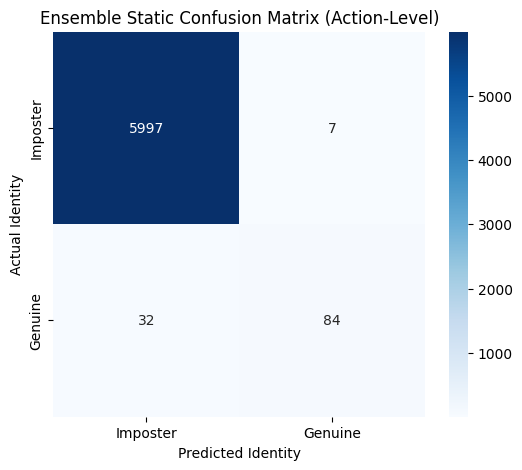

Generating Confidence Trajectory...


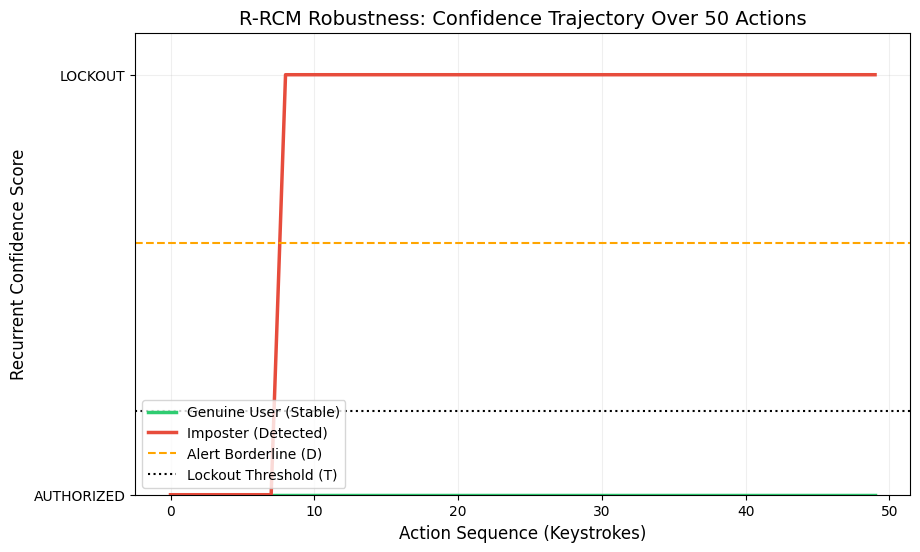

Analysis Complete. Check your folder for 'confusion_matrix.png' and 'confidence_trajectory.png'.


In [11]:

X_test_scaled = ensemble.scaler.transform(X_test)
probs = (ensemble.svm.predict_proba(X_test_scaled)[:, 1] +
         ensemble.rf.predict_proba(X_test_scaled)[:, 1] +
         ensemble.mlp.predict_proba(X_test_scaled)[:, 1]) / 3

y_pred_ensemble = (probs > 0.5).astype(int)


print("Generating Confusion Matrix...")
plot_static_analysis(y_test, y_pred_ensemble)

print("Generating Confidence Trajectory...")
plot_confidence_trajectory(ensemble, X_test, y_test)

print("Analysis Complete. Check your folder for 'confusion_matrix.png' and 'confidence_trajectory.png'.")